# Airline Customer Segmentation with K-Means

## Business Context

An airline marketing team wants to move beyond one-size-fits-all promotions. Customers with similar account tenure but very different mileage balances may respond to different offers, and the same is true for newer versus long-standing loyalty members.

Customer segmentation can turn those behavioral differences into groups that are easier to target with differentiated campaigns.

## Objective

The objective is to use K-Means clustering to identify customer segments based on two variables: `AccountAge` in months and `CurrentMileageBalance`. The notebook explores the feature distributions, uses the elbow method to choose a cluster count, fits the clustering model, and interprets the resulting customer groups.

This is a small illustrative dataset with 20 observations, so the result should be treated as a segmentation demonstration rather than a production-ready customer model.

### Step 1: Import Required Libraries

Load the packages used for tabular data handling, exploratory visualization, and K-Means clustering.

In [1]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import plotly.express as pxp

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

warnings.simplefilter(action="ignore", category=FutureWarning)

### Step 2: Create and Inspect the Customer Dataset

Create the 20-observation sample containing account age and current mileage balance. These two continuous variables represent loyalty tenure and current engagement/value in a simplified form.

In [2]:
data = pd.DataFrame([[60,41000],
[61,46000],
[62,49000],
[63,39000],
[62,45000],
[61,50000],
[60,46000],
[50,76000],
[57,82000],
[60,58000],
[55,80000],
[54,81000],
[57,84000],
[53,81000],
[32,90000],
[36,86000],
[39,90000],
[31,91000],
[37,85000],
[39,88000]],
    columns=['AccountAge', 'CurrentMileageBalance'])
data.head()

,AccountAge,CurrentMileageBalance
0,60,41000
1,61,46000
2,62,49000
3,63,39000
4,62,45000


### Step 3: Explore Feature Distributions

Plot the distributions of account age and mileage balance. This provides a quick view of the range and concentration of each feature before clustering.

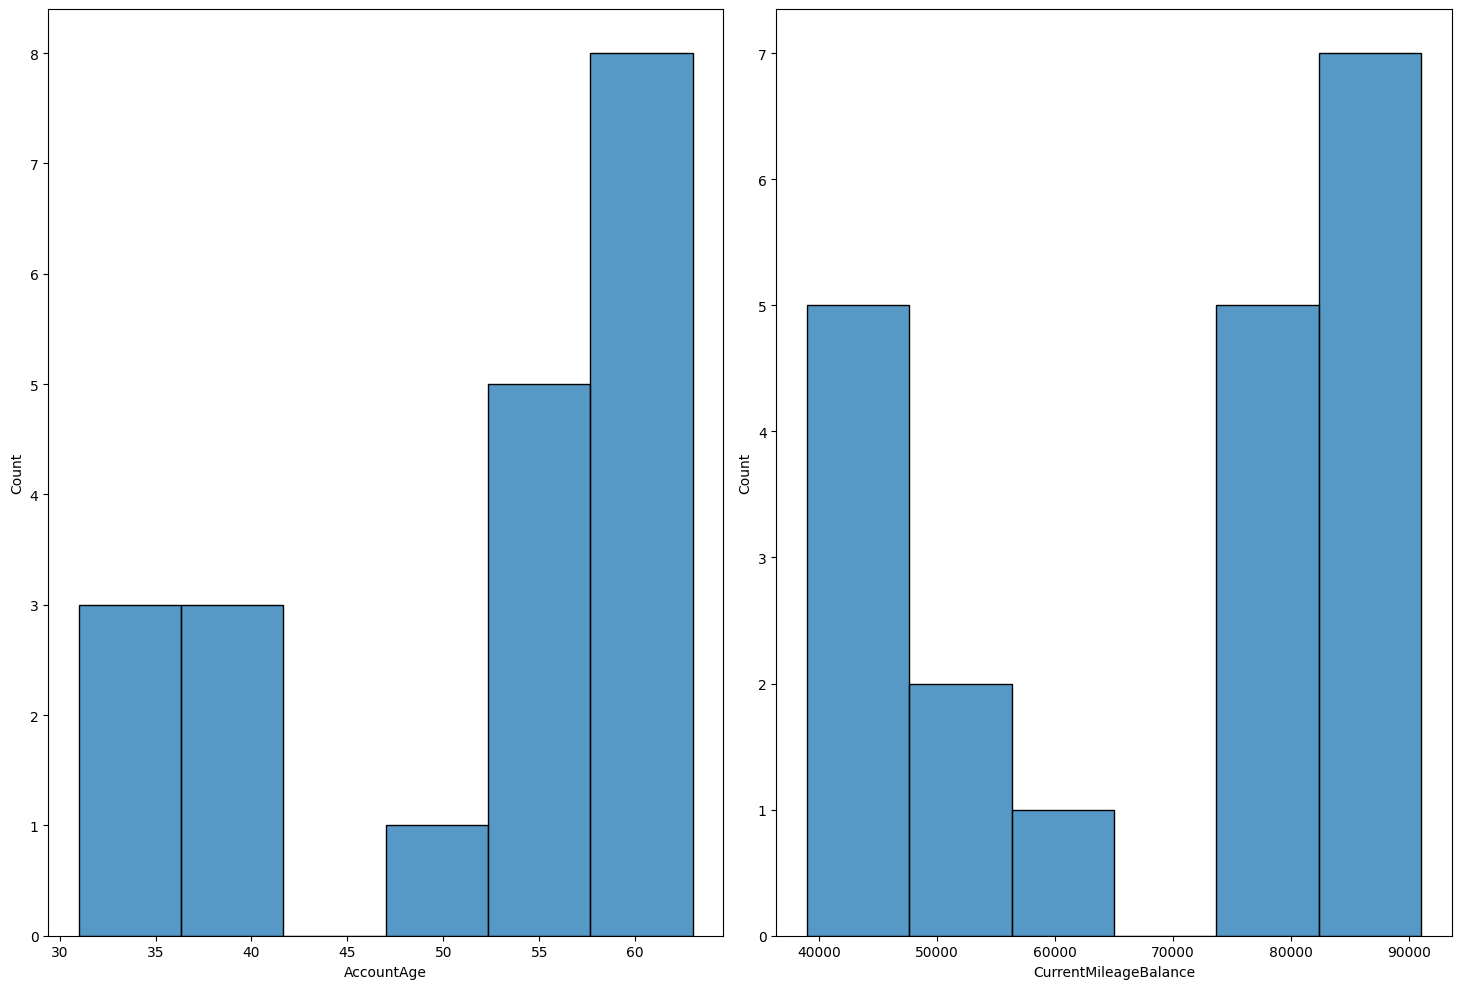

In [3]:
plt.figure(figsize = (22, 10))
plotnum = 1

for cols in ['AccountAge', 'CurrentMileageBalance']:
    if plotnum <= 2:
        axs = plt.subplot(1, 3, plotnum)
        sns.histplot(data[cols])

    plotnum += 1

plt.tight_layout()
plt.show()

### Step 4: Review Account-Age Ranges

Group account age into broader tenure bands and visualize the number of customers in each range. This makes the raw age distribution easier to interpret from a marketing perspective.

In [4]:
time_above_71 = data.AccountAge[data.AccountAge >= 71]
time_56_70 = data.AccountAge[data.AccountAge.between(56, 70)]
time_41_55 = data.AccountAge[data.AccountAge.between(41, 55)]
time_26_40 = data.AccountAge[data.AccountAge.between(26, 40)]
time_0_25 = data.AccountAge[data.AccountAge.between(0, 25)]

x_age_ax = ['0-25', '26-40', '41-55', '56-70', '71+']
y_age_ax = [len(time_0_25.values), len(time_26_40.values), len(time_41_55.values),
            len(time_56_70.values), len(time_above_71.values)]

pxp.bar(data_frame = data, x = x_age_ax, y = y_age_ax, color = x_age_ax,
       title = 'Count of Accounts by Age (Months)')

### Step 5: Estimate the Number of Clusters

Use the elbow method by fitting K-Means across several values of `k` and plotting within-cluster sum of squares (WCSS). The goal is to find a point where adding more clusters provides diminishing improvement in compactness.

The notebook proceeds with **three clusters**, providing a manageable number of customer groups for interpretation and campaign design.

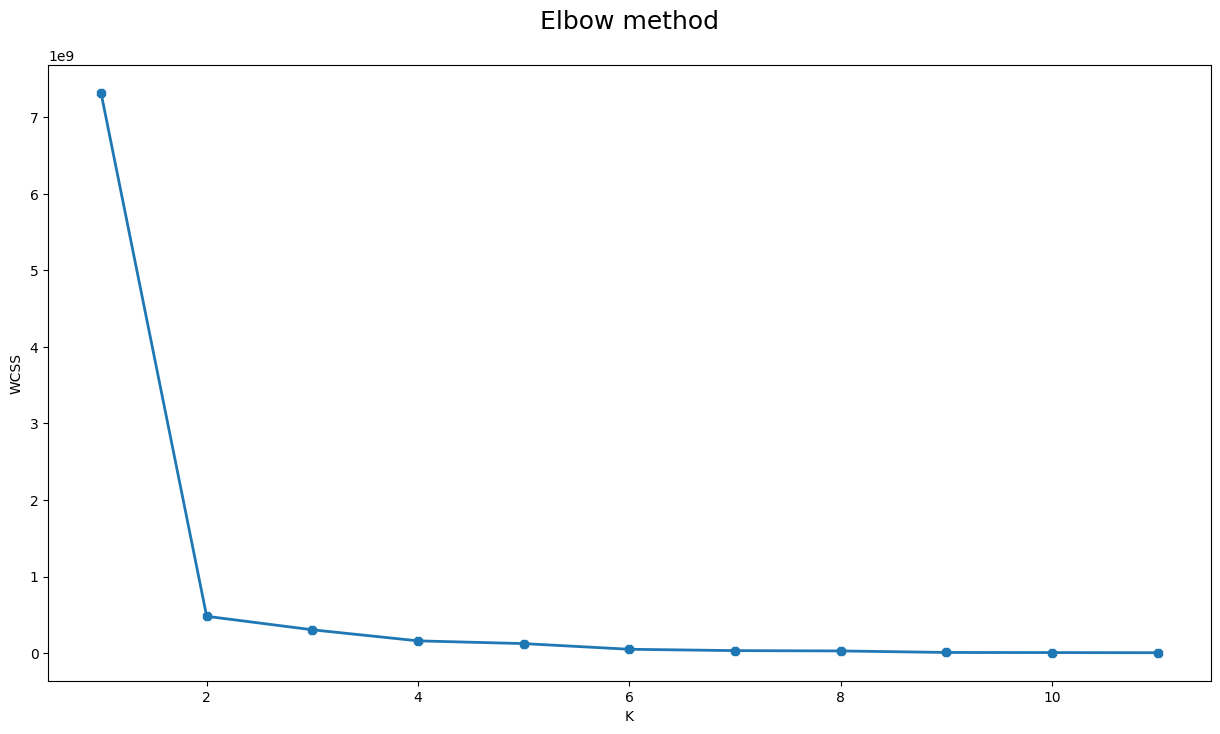

In [5]:
import scipy

x_input = data.loc[:, ['AccountAge', 'CurrentMileageBalance']].values
wcss = []
for k in range(1,12):
    kmeans = KMeans(k,random_state = 0,init='k-means++').fit(x_input)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(15,8))

plt.plot(range(1, 12), wcss, linewidth=2, marker='8')
plt.title('Elbow method\n', fontsize=18)
plt.xlabel('K')
plt.ylabel('WCSS')
ax = plt.gca() # get axis handle
line = ax.get_lines()[0]
xydata = line.get_xydata()
plt.show()


### Step 6: Fit the K-Means Model

Fit K-Means with three clusters and assign each customer to a segment. The stored cluster centers are approximately:

- **54.3 months / 80,667 miles**
- **61.1 months / 46,750 miles**
- **35.7 months / 88,333 miles**

The centers summarize the typical tenure and mileage balance of each discovered segment.

In [6]:
k_means = KMeans(3,random_state = 0,init='k-means++').fit(x_input)
labels = k_means.fit_predict(x_input)
ClusterCenters = k_means.cluster_centers_
print(ClusterCenters)



[[5.43333333e+01 8.06666667e+04]
 [6.11250000e+01 4.67500000e+04]
 [3.56666667e+01 8.83333333e+04]]


### Step 7: Visualize and Interpret the Segments

Plot the customers by account age and mileage balance, color them by assigned cluster, and display the cluster centers. The visualization makes it easier to judge whether the groups are meaningfully separated and how their profiles differ.

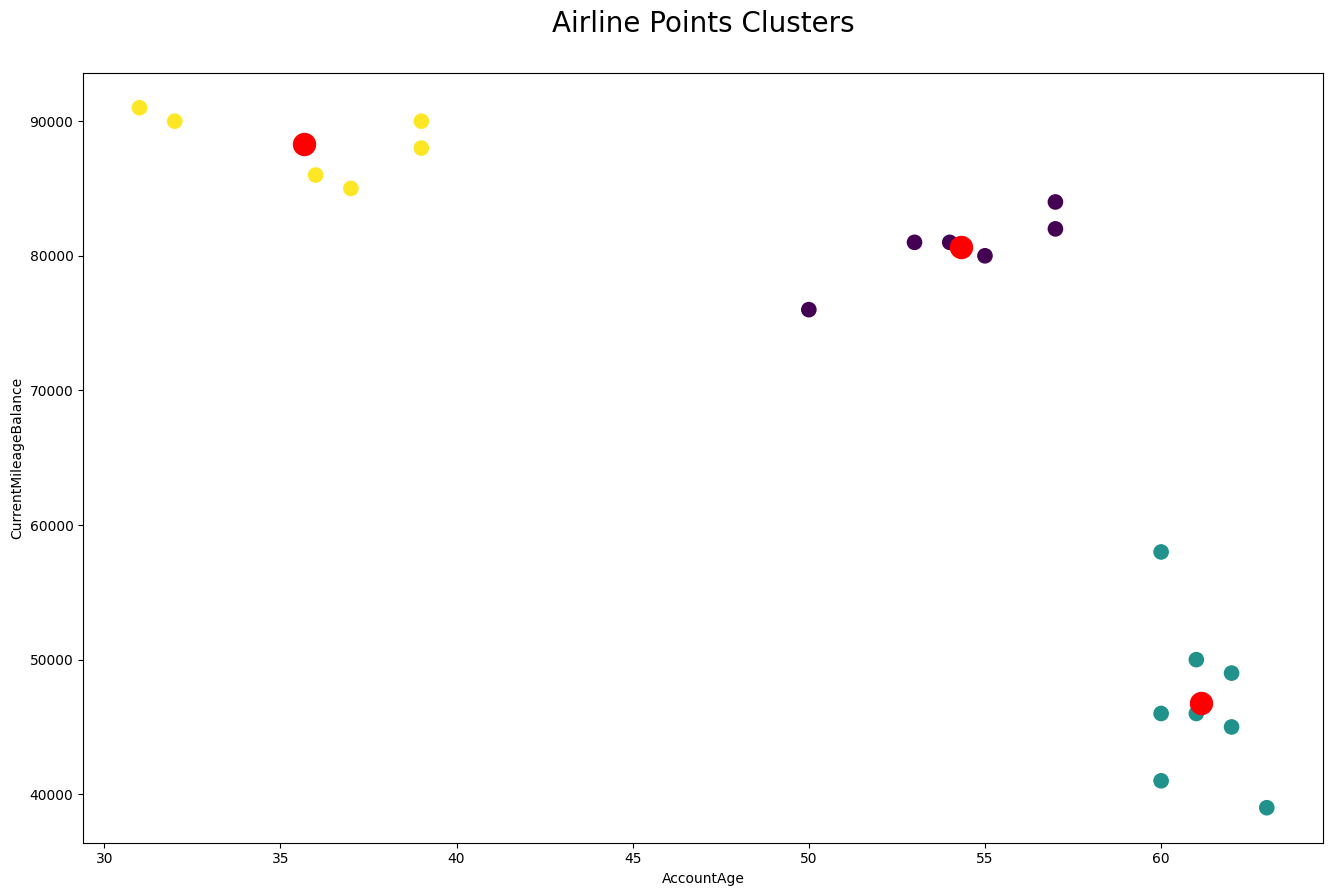

In [7]:
plt.figure(figsize=(16, 10))

scatter_points = plt.scatter(
    x_input[:,0],
    x_input[:,1],
    s=105,
    c=labels
)
fig = plt.scatter(
    ClusterCenters[:, 0],
    ClusterCenters[:, 1],
    s=250,
    c='r'
)

plt.title('Airline Points Clusters\n', fontsize=20)
plt.xlabel('AccountAge')
plt.ylabel('CurrentMileageBalance')
plt.show()

points = fig.get_offsets()

## Conclusions

### Technical Takeaways

The three-cluster solution separates the sample into distinct combinations of tenure and mileage balance. The cluster centers suggest a newer high-mileage group, a mid-tenure high-mileage group, and a longer-tenure lower-mileage group.

There are two important limitations. First, the dataset contains only 20 manually defined observations, so the clusters should not be treated as stable population segments. Second, K-Means is distance-based and the features are not standardized in the current code. Because mileage balance has a much larger numeric scale than account age, it can dominate the distance calculation.

For a production model, feature scaling should be evaluated, clustering stability should be tested across samples and random initializations, and the solution should be validated with metrics such as silhouette score in addition to the elbow method.

### Business Takeaways

Even this simple segmentation illustrates how a marketing team can move from broad campaigns to differentiated treatment. High-mileage customers with shorter tenure may be good candidates for retention or status-acceleration offers, while long-tenure customers with lower balances may require re-engagement strategies.

The clusters should be treated as starting hypotheses for campaign design rather than final customer personas. Their real value would come from linking them to response rate, booking frequency, revenue, route preference, and loyalty-tier behavior.

### Next Steps

The next iteration should use a larger customer dataset, standardize the features, add richer behavioral variables, and test whether the segments remain stable over time. Campaign experiments can then measure whether segment-specific offers outperform a single generic promotion.

The notebook code contains the complete clustering workflow used to generate and visualize the current segments.